# Bevölkerung nach Bildungsstand

bfs_bev_bildungsstand_seit1970_od1002 

### Kurzbeschreibung
Diese Daten beschreiben die ständige Wohnbevölkerung der Stadt Zürich und basieren auf der Volkszählung und der Strukturerhebung des Bundesamts für Statistik.

Es sind bloss 15-jährige und ältere Personen enthalten. Weitere Informationen finden Sie unter Bemerkung.

Datum: 03.03.2025


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_seit1970_od1002

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_bildungsstand_seit1970_od1002


### Importiere die notwendigen Packages

In [12]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [13]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [14]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [15]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [16]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [17]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [18]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [19]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [20]:
package_name = "bfs_bev_bildungsstand_seit1970_od1002"

In [21]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BIL100OD1002"    
    , datums_attr = ['Jahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_seit1970_od1002/download/BIL100OD1002.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_seit1970_od1002 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_seit1970_od1002 

data_source: web


In [22]:
data2betested.head(2).T

,0,1
Jahr,1970-01-01 00:00:00,1970-01-01 00:00:00
Bildungsstand,Ohne nachobligatorische Ausbildung,Sekundarstufe II
AntBev,32,58
untAntBevKI,NaN,NaN
obAntBevKI,NaN,NaN


Berechne weitere Attribute falls notwendig

In [23]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.Jahr.astype(str),
        Jahr_end = lambda x: x.Jahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr_end', ascending=False)
    )
data2betested.dtypes

Jahr                   datetime64[ns]
Bildungsstand                  object
AntBev                        float64
untAntBevKI                   float64
obAntBevKI                    float64
StichtagDatJahr_str            object
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [24]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1970-12-31 und ein Maximumjahr von 2023-12-31


### Einfache Datentests

In [25]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 53 to 0
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Jahr                 54 non-null     datetime64[ns]
 1   Bildungsstand        54 non-null     object        
 2   AntBev               54 non-null     float64       
 3   untAntBevKI          42 non-null     float64       
 4   obAntBevKI           42 non-null     float64       
 5   StichtagDatJahr_str  54 non-null     object        
 6   Jahr_end             54 non-null     datetime64[ns]
 7   Jahr_nbr             54 non-null     int32         
dtypes: datetime64[ns](2), float64(3), int32(1), object(2)
memory usage: 10.8 KB


In [26]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 54 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [27]:
data2betested.describe()

,Jahr,AntBev,untAntBevKI,obAntBevKI,Jahr_end,Jahr_nbr
count,54,54,42,42,54,54
mean,2009-07-02 05:20:00,33,32,34,2010-07-01 12:00:00,2010
min,1970-01-01 00:00:00,10,14,16,1970-12-31 00:00:00,1970
25%,2010-01-01 00:00:00,20,19,20,2010-12-31 00:00:00,2010
50%,2014-07-02 12:00:00,33,32,34,2015-07-01 12:00:00,2014
75%,2019-01-01 00:00:00,45,42,44,2019-12-31 00:00:00,2019
max,2023-01-01 00:00:00,59,58,60,2023-12-31 00:00:00,2023
std,NaN,14,14,14,NaN,15


Welches sind die Quartiere ohne Werte bei BEW?

In [28]:
data2betested[np.isnan(data2betested.AntBev)]

,Jahr,Bildungsstand,AntBev,untAntBevKI,obAntBevKI,StichtagDatJahr_str,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [29]:
data2betested = data2betested.set_index("Jahr_end")
data2betested = data2betested.sort_index()

In [30]:
data2betested.index.year.unique()

Index([1970, 1980, 1990, 2000, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023],
      dtype='int32', name='Jahr_end')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [31]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,Jahr,Bildungsstand,StichtagDatJahr_str
count,54,54,54
unique,NaN,3,18
top,NaN,Ohne nachobligatorische Ausbildung,1970-01-01
freq,NaN,18,3
mean,2009-07-02 05:20:00,NaN,NaN
min,1970-01-01 00:00:00,NaN,NaN
25%,2010-01-01 00:00:00,NaN,NaN
50%,2014-07-02 12:00:00,NaN,NaN
75%,2019-01-01 00:00:00,NaN,NaN
max,2023-01-01 00:00:00,NaN,NaN


Beschreibe numerische Attribute

In [32]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AntBev,untAntBevKI,obAntBevKI,Jahr_nbr
count,54,42,42,54
mean,33,32,34,"2,010"
std,14,14,14,15
min,10,14,16,"1,970"
25%,20,19,20,"2,010"
50%,33,32,34,"2,014"
75%,45,42,44,"2,019"
max,59,58,60,"2,023"


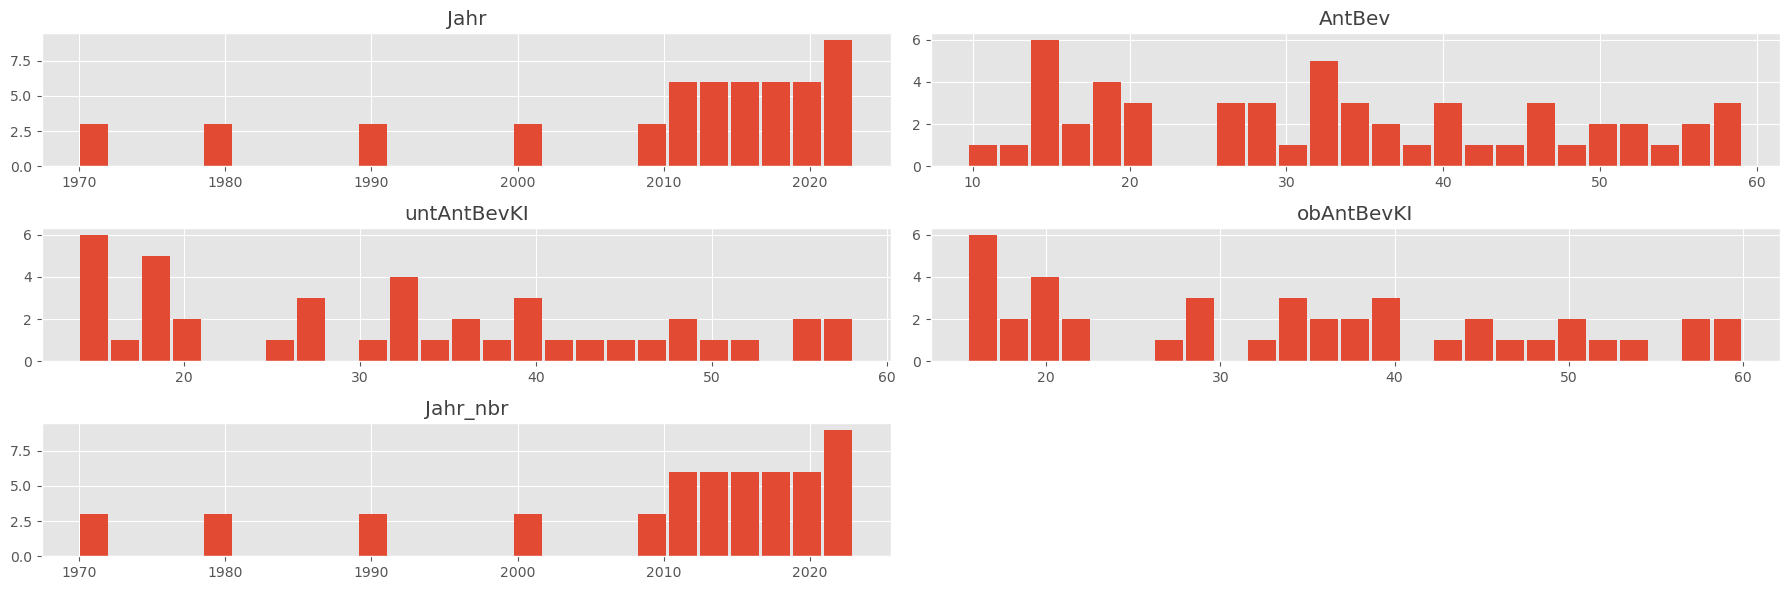

In [33]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [34]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Jahr,Bildungsstand,AntBev,untAntBevKI,obAntBevKI,StichtagDatJahr_str,Jahr_nbr
Jahr_end,,,,,,,


### Nullwerte und Missings?

In [35]:
data2betested.isnull().sum()

Jahr                    0
Bildungsstand           0
AntBev                  0
untAntBevKI            12
obAntBevKI             12
StichtagDatJahr_str     0
Jahr_nbr                0
dtype: int64

In [36]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [37]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,2023-01-01,2023,33,26,32,25,34,27
1,2022-01-01,2022,33,27,32,26,34,28
2,2021-01-01,2021,33,28,32,28,34,29


In [38]:
agg_bildungsstand = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Bildungsstand']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('Bildungsstand', ascending=False) 
agg_bildungsstand.reset_index().head(3)

,Bildungsstand,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,Tertiärstufe,42,46,48,48,50,50
1,Sekundarstufe II,37,35,32,32,34,34
2,Ohne nachobligatorische Ausbildung,21,19,17,17,18,18


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [39]:
data2betested

,Jahr,Bildungsstand,AntBev,untAntBevKI,obAntBevKI,StichtagDatJahr_str,Jahr_nbr
Jahr_end,,,,,,,
1970-12-31,1970-01-01,Ohne nachobligatorische Ausbildung,32,NaN,NaN,1970-01-01,1970
1970-12-31,1970-01-01,Sekundarstufe II,58,NaN,NaN,1970-01-01,1970
1970-12-31,1970-01-01,Tertiärstufe,10,NaN,NaN,1970-01-01,1970
1980-12-31,1980-01-01,Ohne nachobligatorische Ausbildung,34,NaN,NaN,1980-01-01,1980
1980-12-31,1980-01-01,Sekundarstufe II,52,NaN,NaN,1980-01-01,1980
1980-12-31,1980-01-01,Tertiärstufe,14,NaN,NaN,1980-01-01,1980
1990-12-31,1990-01-01,Ohne nachobligatorische Ausbildung,31,NaN,NaN,1990-01-01,1990
1990-12-31,1990-01-01,Sekundarstufe II,54,NaN,NaN,1990-01-01,1990
1990-12-31,1990-01-01,Tertiärstufe,15,NaN,NaN,1990-01-01,1990


In [40]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc["1970":data_max_date]\
    .groupby(['Jahr', 'Jahr_end', 'Bildungsstand']) \
    .agg(mean_AntBev=('AntBev', 'mean'), median_AntBev=('AntBev', 'sum'), mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median'), mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')) \
    .sort_values('Jahr', ascending=False) 

myAgg1.reset_index().head(3)

,Jahr,Jahr_end,Bildungsstand,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,2023-01-01,2023-12-31,Tertiärstufe,59,59,58,58,60,60
1,2023-01-01,2023-12-31,Sekundarstufe II,26,26,25,25,27,27
2,2023-01-01,2023-12-31,Ohne nachobligatorische Ausbildung,15,15,14,14,16,16


In [41]:
data2betested.columns

Index(['Jahr', 'Bildungsstand', 'AntBev', 'untAntBevKI', 'obAntBevKI', 'StichtagDatJahr_str',
       'Jahr_nbr'],
      dtype='object')

In [42]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'AntBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands in der Stadt Zürich, seit "+data_min_date
)

grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'untAntBevKI:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands (unteres KI) in der Stadt Zürich, seit "+data_min_date
)

grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'obAntBevKI:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands (oberes KI) in der Stadt Zürich, seit "+data_min_date
)


##### Kombinierte Grafik in Altair

In [43]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, grafik3, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Barcharts mit Seaborn

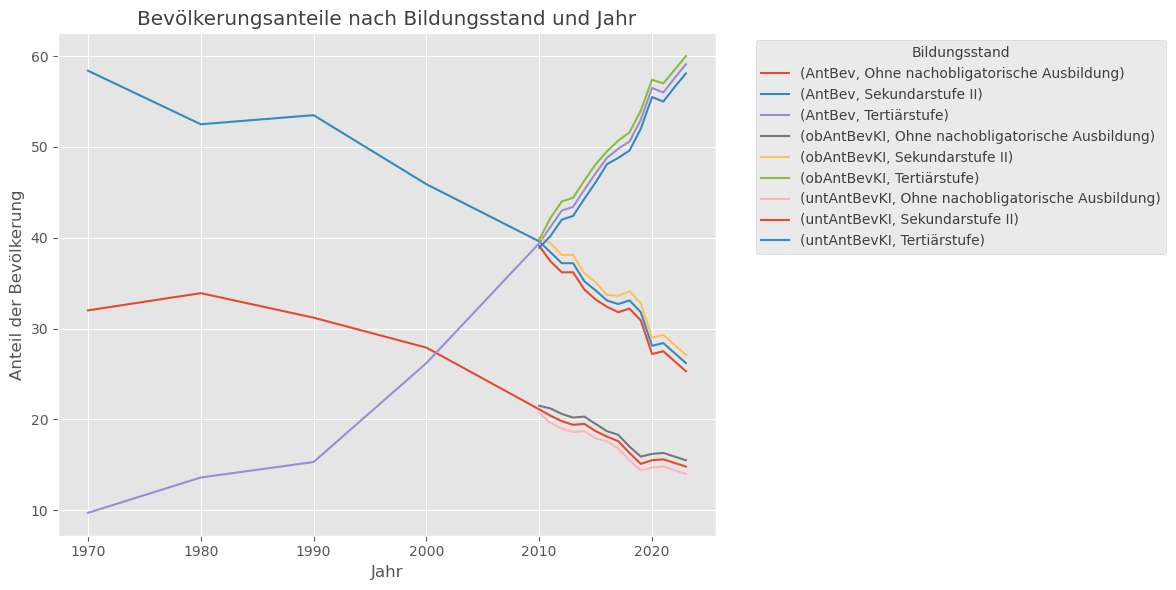

In [44]:

# Gruppieren Sie die Daten nach Jahr und Bildungsstand
grouped = data2betested.pivot_table(values=['AntBev','obAntBevKI','untAntBevKI'], index='Jahr_nbr', columns='Bildungsstand', aggfunc='mean')

# Erstellen Sie data2betested gruppierte Balkendiagramm
ax = grouped.plot(kind='line', figsize=(12, 6))

# Anpassen des Diagramms
plt.title('Bevölkerungsanteile nach Bildungsstand und Jahr')
plt.xlabel('Jahr')
plt.ylabel('Anteil der Bevölkerung')
plt.legend(title='Bildungsstand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()




In [45]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")


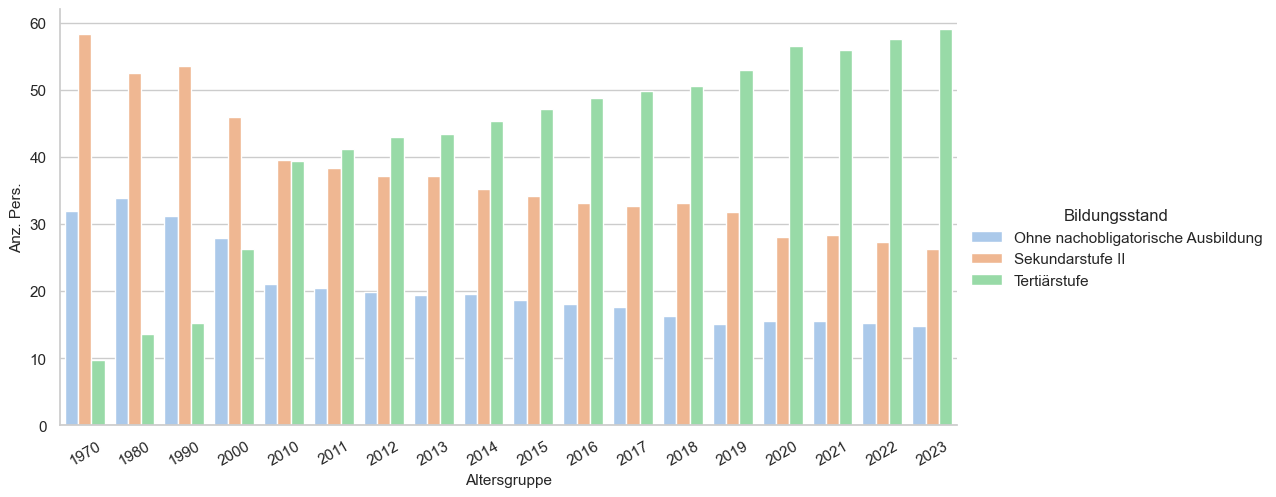

In [46]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="AntBev"
            , hue="Bildungsstand"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=data2betested.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [47]:
data2betested.columns

Index(['Jahr', 'Bildungsstand', 'AntBev', 'untAntBevKI', 'obAntBevKI', 'StichtagDatJahr_str',
       'Jahr_nbr'],
      dtype='object')

In [48]:

melted_df = data2betested.reset_index().melt(id_vars=['Jahr_end', 'Bildungsstand'], value_vars=['AntBev', 'untAntBevKI', 'obAntBevKI'])
melted_df



,Jahr_end,Bildungsstand,variable,value
0,1970-12-31,Ohne nachobligatorische Ausbildung,AntBev,32
1,1970-12-31,Sekundarstufe II,AntBev,58
2,1970-12-31,Tertiärstufe,AntBev,10
3,1980-12-31,Ohne nachobligatorische Ausbildung,AntBev,34
4,1980-12-31,Sekundarstufe II,AntBev,52
...,...,...,...,...
157,2022-12-31,Sekundarstufe II,obAntBevKI,28
158,2022-12-31,Tertiärstufe,obAntBevKI,58
159,2023-12-31,Ohne nachobligatorische Ausbildung,obAntBevKI,16
160,2023-12-31,Sekundarstufe II,obAntBevKI,27


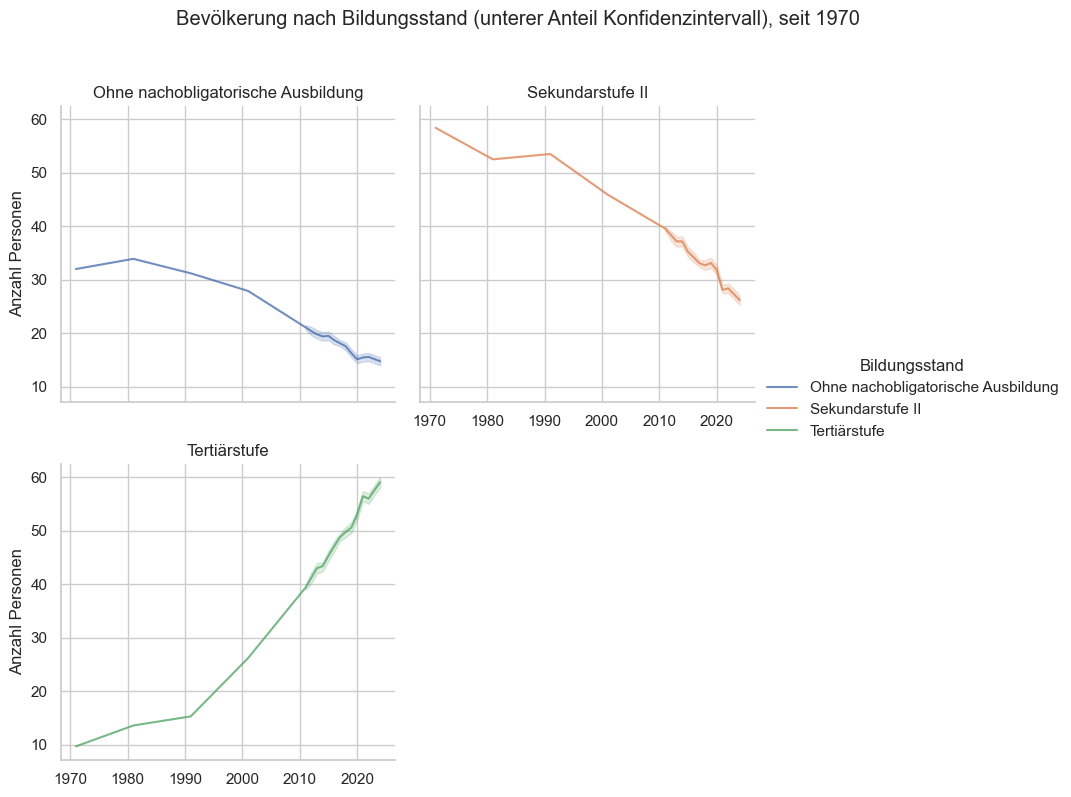

In [49]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = melted_df.reset_index().sort_values('Jahr_end', ascending=True)
    ,col = "Bildungsstand"
    ,hue = "Bildungsstand"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "value"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand (unterer Anteil Konfidenzintervall), seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

(<seaborn.axisgrid.FacetGrid at 0x20fc7096b10>,
 <seaborn.axisgrid.FacetGrid at 0x20fc6e2a210>)

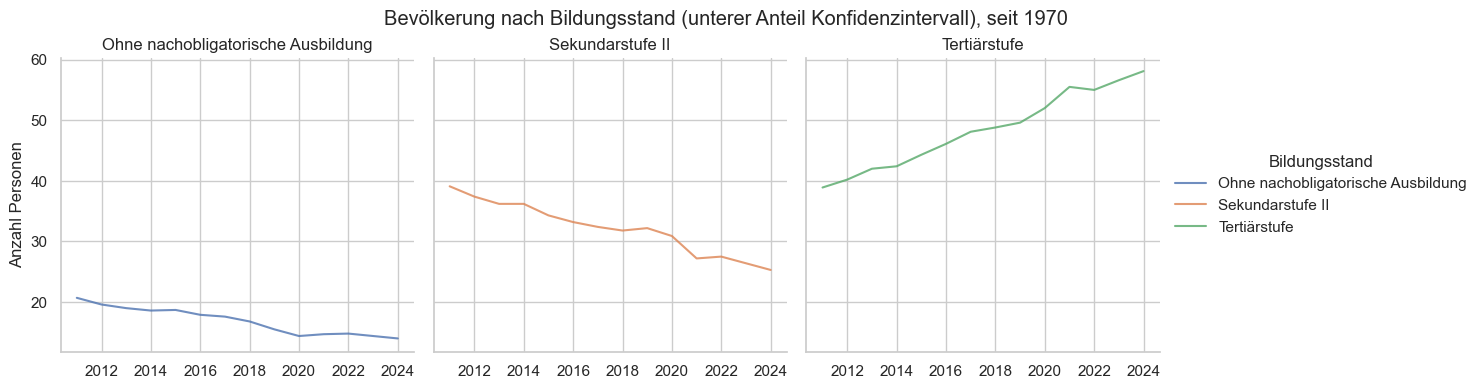

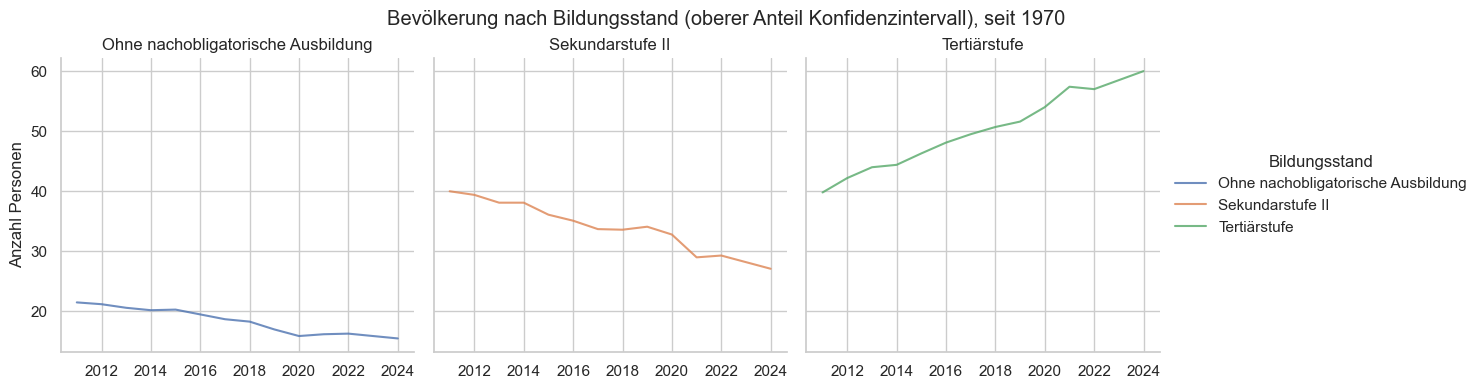

In [50]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('Jahr_nbr', ascending=True)
    ,col = "Bildungsstand"
    ,hue = "Bildungsstand"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "untAntBevKI"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand (unterer Anteil Konfidenzintervall), seit "+str(int(data2betested.index.year.min()))
)
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('Jahr_nbr', ascending=True)
    ,col = "Bildungsstand"
    ,hue = "Bildungsstand"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "obAntBevKI"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand (oberer Anteil Konfidenzintervall), seit "+str(int(data2betested.index.year.min()))
)
faced_grid1, faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [51]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [52]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['Bildungsstand'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Ohne nachobligatorische Ausbildung': '#0017BF', 'Sekundarstufe II': '#0072D7', 'Tertiärstufe': '#00A5D2'}


##### Bevölkerung nach Bildungsstand

In [53]:
data2betested.reset_index().columns

Index(['Jahr_end', 'Jahr', 'Bildungsstand', 'AntBev', 'untAntBevKI', 'obAntBevKI',
       'StichtagDatJahr_str', 'Jahr_nbr'],
      dtype='object')

In [54]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index()
    ,levels=['Bildungsstand','Jahr_nbr']
    ,values="AntBev"
    ,color="Bildungsstand"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Bevölkerung nach Bildungsstand, seit "+ data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000020FC6E17C10>, 'Bildungsstand', 'Jahr_nbr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=353&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------